# nb07 — форма распределения PnL: правда ли убытки большие, а прибыли маленькие?

Вопрос пользователя дословно: «посмотрим распределение минусов, насколько я
понимаю они максимально большие да, а прибыли малые?»

Это не праздный вопрос — от ответа зависит, **чем лечить**. Три разных диагноза
требуют трёх разных лекарств:

| если окажется | значит | лекарство |
|---|---|---|
| убыток широкий, размазан по всем сделкам | edge просто отрицательный | менять сигнал, а не риск-менеджмент |
| убыток в редком толстом хвосте, остальное ≈ 0 | средняя сделка честная, убивает хвост | стоп / лимит удержания / контроль концентрации |
| прибыли ограничены правилом, убытки нет | асимметрия **создана нами** | менять правило выхода, а не искать сигнал |

Ключевая ловушка, которую надо обойти: правило «вход 2σ → цель 0.5σ → стоп 4σ»
асимметрично **по построению**. Прибыль ограничена сверху ходом 1.5σ, убыток по
стопу равен 2σ, а убыток по таймауту не ограничен вообще. То есть отрицательную
скошенность мы получим даже на чистом случайном блуждании. Поэтому всё меряется
**рядом с синтетикой**.

Работаем на том же материале, что nb06: TRAIN, 1h, 43 ликвидных символа,
ежедневный рефит ADF, окна формации 3 и 7 дней, режим REFIT.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
# EG асимметричен: слева менее ликвидная нога (как в nb06)
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
COST = ROUND_TRIP_BPS / 100
print(f"символов {len(liq)}, пар {len(bk.PAIRS)}, баров {len(bk.index)} по {bk.bar_min}м")
print(f"{bk.index[0]} .. {bk.index[-1]}, кост round-trip {COST:.2f}% от gross")

символов 43, пар 903, баров 13151 по 60м
2024-01-01 00:00:00+00:00 .. 2025-07-01 22:00:00+00:00, кост round-trip 0.21% от gross


## 0. Контроль рефакторинга

Движок nb06 вынесен в `_engine.py`, чтобы не копировать его в каждый ноутбук.
Прежде чем что-то на нём измерять, надо убедиться, что он воспроизводит nb06
**число в число** — иначе все дальнейшие выводы будут про новый код, а не про то,
что мы уже поняли.

In [2]:
LD = [3, 7]
THR_NB06 = {3: -3.341, 7: -3.545}       # пороги, откалиброванные в nb06
REF, TRD, THR_MINE = {}, {}, {}
for L in LD:
    t0 = time.time()
    n = bk.nbars(L)
    THR_MINE[L] = calibrate_thr(bk, n)
    R = refit(bk, n, THR_NB06[L])
    d = sweep(bk, R, "REFIT", cost_pct=COST)
    REF[L], TRD[L] = R, d
    print(f"L={L}д: порог nb06 t={THR_NB06[L]:.3f}, рефитов {len(R.ends)}, "
          f"отобрано {R.sel.sum(axis=1).mean():.0f} пар/день, "
          f"сделок {len(d)}, среднее {d.pnl.mean():+.3f}%, {time.time()-t0:.0f}s")

REFERENCE = {3: (57690, -0.165), 7: (25147, -0.192)}   # из nb06
print("\nСВЕРКА С nb06 (режим REFIT, порог взят из nb06):")
for L in LD:
    n_ref, m_ref = REFERENCE[L]
    d = TRD[L]
    ok = abs(len(d) - n_ref)/n_ref < 0.02 and abs(d.pnl.mean() - m_ref) < 0.005
    print(f"  L={L}д: сделок {len(d)} против {n_ref}, среднее {d.pnl.mean():+.3f}% "
          f"против {m_ref:+.3f}%  ->  {'СОВПАЛО' if ok else '!! РАСХОЖДЕНИЕ'}")

print("""
!! ПОБОЧНАЯ НАХОДКА, которую нельзя проигнорировать.

Свежая калибровка того же порога на тех же данных дала ДРУГОЕ число:""")
for L in LD:
    print(f"   L={L}д: nb06 {THR_NB06[L]:+.3f}  против  повторной калибровки "
          f"{THR_MINE[L]:+.3f}   (разница {THR_MINE[L]-THR_NB06[L]:+.3f})")
print("""
Причина понятна: порог — это 5-й процентиль t-статистики по ~2700 синтетическим
тестам, и сегменты, на которых строится синтетика, в двух реализациях разные.
Сама по себе разница 0.08-0.19 единиц t выглядит мелкой, но она сдвигает отбор:
с моим (более мягким) порогом сделок становится 65254 вместо 57690, то есть +13%.

А это значит, что вывод nb06 «gross на коротких окнах положителен» надо проверить
на устойчивость к порогу — иначе мы не знаем, реальный это эффект или он держится
на конкретном значении отсечки. Этим и займёмся в §0b, прежде чем изучать форму
распределения.""")

L=3д: порог nb06 t=-3.341, рефитов 546, отобрано 80 пар/день, сделок 57836, среднее -0.165%, 12s


L=7д: порог nb06 t=-3.545, рефитов 542, отобрано 58 пар/день, сделок 25175, среднее -0.191%, 12s

СВЕРКА С nb06 (режим REFIT, порог взят из nb06):
  L=3д: сделок 57836 против 57690, среднее -0.165% против -0.165%  ->  СОВПАЛО
  L=7д: сделок 25175 против 25147, среднее -0.191% против -0.192%  ->  СОВПАЛО

!! ПОБОЧНАЯ НАХОДКА, которую нельзя проигнорировать.

Свежая калибровка того же порога на тех же данных дала ДРУГОЕ число:
   L=3д: nb06 -3.341  против  повторной калибровки -3.265   (разница +0.076)
   L=7д: nb06 -3.545  против  повторной калибровки -3.355   (разница +0.190)

Причина понятна: порог — это 5-й процентиль t-статистики по ~2700 синтетическим
тестам, и сегменты, на которых строится синтетика, в двух реализациях разные.
Сама по себе разница 0.08-0.19 единиц t выглядит мелкой, но она сдвигает отбор:
с моим (более мягким) порогом сделок становится 65254 вместо 57690, то есть +13%.

А это значит, что вывод nb06 «gross на коротких окнах положителен» надо проверить
на устойчивос

## 0b. Устойчивость к порогу отбора (и работает ли ADF-фильтр вообще)

Порог ADF — единственная ручка, которая решает, какие пары попадают в торговлю.
Меняем её широким шагом и смотрим на **gross** (то, что дал спред, без костов).

Три исхода, и они означают разное:

- **gross растёт при более строгом пороге** → фильтр отбирает что-то настоящее,
  и надо идти в сторону строгости;
- **gross плоский** → ADF-фильтр не несёт информации, а весь результат создаёт
  правило по z; тогда «коинтеграция» в этой стратегии просто декорация;
- **gross положителен только у одного значения** → эффект — артефакт подгонки.

Отдельная строка — **вообще без фильтра коинтеграции** (только β>0). Это тот
контроль, которого нам до сих пор не хватало: он прямо отвечает, добавляет ли
тест хоть что-нибудь к торговле z-отклонения любой пары.

`T`, `β`, `mean`, `sd` от порога не зависят, поэтому рефит переиспользуем и меняем
только маску отбора — сравнение получается чистым.

  L=3д thr=-4.6: 5236 сделок, gross +0.0159%, ход +0.0353σ


  L=3д thr=-4.2: 11914 сделок, gross +0.0452%, ход +0.0570σ


  L=3д thr=-3.8: 25653 сделок, gross +0.0599%, ход +0.0650σ


  L=3д thr=-3.341: 57836 сделок, gross +0.0450%, ход +0.0475σ


  L=3д thr=-3.2: 72211 сделок, gross +0.0454%, ход +0.0481σ


...

  L=7д thr=-2.8: 73340 сделок, gross -0.0276%, ход +0.0146σ


  L=7д thr=-2.0: 138511 сделок, gross -0.0404%, ход -0.0056σ


  L=7д thr=нет фильтра: 197192 сделок, gross -0.0748%, ход -0.0326σ

ЧУВСТВИТЕЛЬНОСТЬ К ПОРОГУ ОТБОРА
 L, дн     порог t  % пар отобрано  сделок  GROSS %  ход в σ  NET taker %  % плюс gross  σ спреда, %  медиана ч
     3        -4.6             0.7    5236   0.0159   0.0353      -0.1941          46.2        0.444          5
     3        -4.2             1.7   11914   0.0452   0.0570      -0.1648          46.6        0.449          6
     3        -3.8             3.7   25653   0.0599   0.0650      -0.1501          46.8        0.459          6
     3      -3.341             8.9   57836   0.0450   0.0475      -0.1650          46.8        0.491          6
     3        -3.2            11.3   72211   0.0454   0.0481      -0.1646          46.9        0.501          6
     3        -2.8            21.2  124824   0.0274   0.0278      -0.1826          47.1        0.535          6
     3        -2.0            52.5  253841   0.0028  -0.0008      -0.2072          47.5        0.619          7
  

[saved] notebooks\statarb\_out\nb07_threshold.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb07_threshold.png')

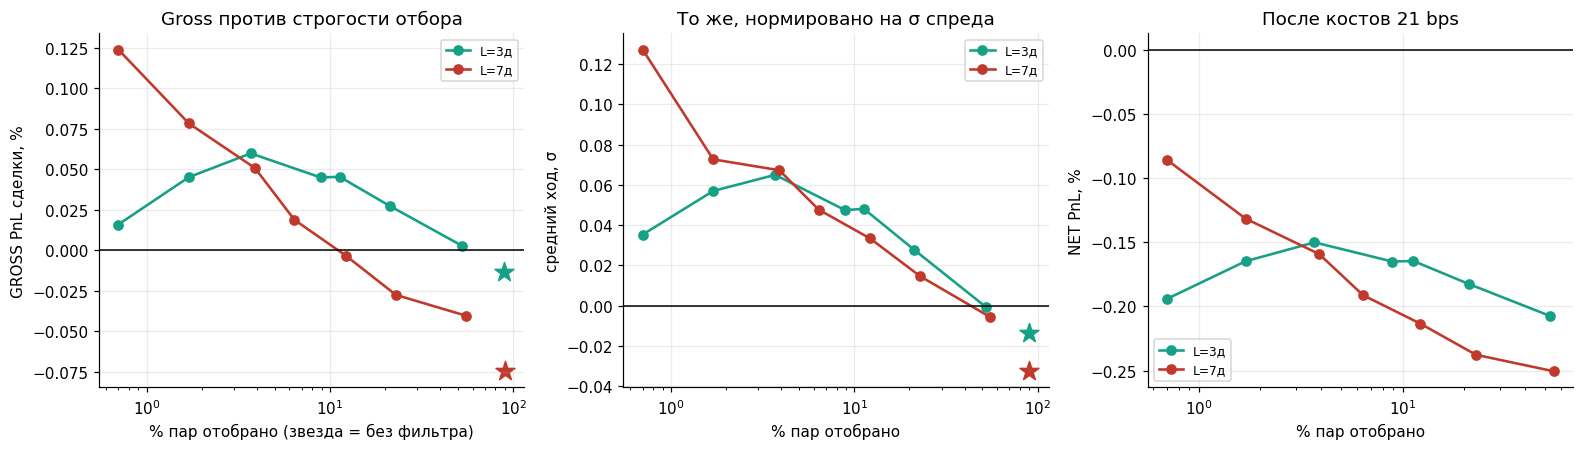

In [3]:
from dataclasses import replace

rows = []
for L in LD:
    R0 = REF[L]
    grid = [-4.6, -4.2, -3.8, THR_NB06[L], -3.2, -2.8, -2.0, np.inf]
    for thr in grid:
        R = replace(R0, thr=thr)
        share = R.sel.mean()*100
        d = sweep(bk, R, "REFIT", cost_pct=COST)
        if not len(d):
            continue
        rows.append({"L, дн": L, "порог t": round(thr, 3) if np.isfinite(thr) else "нет фильтра",
                     "% пар отобрано": round(share, 1), "сделок": len(d),
                     "GROSS %": round(d.gross.mean(), 4),
                     "ход в σ": round(d.sigma.mean(), 4),
                     "NET taker %": round(d.pnl.mean(), 4),
                     "% плюс gross": round((d.gross > 0).mean()*100, 1),
                     "σ спреда, %": round(d.sd_pct.median(), 3),
                     "медиана ч": int(d.hours.median())})
        print(f"  L={L}д thr={rows[-1]['порог t']}: {len(d)} сделок, "
              f"gross {d.gross.mean():+.4f}%, ход {d.sigma.mean():+.4f}σ")
SENS = pd.DataFrame(rows)
print("\nЧУВСТВИТЕЛЬНОСТЬ К ПОРОГУ ОТБОРА")
print(SENS.to_string(index=False))
print()
for L in LD:
    d = SENS[SENS["L, дн"] == L]
    nof = d[d["порог t"] == "нет фильтра"]
    fil = d[d["порог t"] != "нет фильтра"]
    print(f"L={L}д:")
    print(f"  gross по всей сетке порогов: от {fil['GROSS %'].min():+.4f}% до "
          f"{fil['GROSS %'].max():+.4f}% (разброс {fil['GROSS %'].max()-fil['GROSS %'].min():.4f} п.п.)")
    print(f"  ход в σ: от {fil['ход в σ'].min():+.4f} до {fil['ход в σ'].max():+.4f}")
    if len(nof):
        print(f"  БЕЗ фильтра коинтеграции: gross {nof['GROSS %'].iloc[0]:+.4f}%, "
              f"ход {nof['ход в σ'].iloc[0]:+.4f}σ, сделок {int(nof['сделок'].iloc[0])}")
        best = fil.sort_values("ход в σ", ascending=False).iloc[0]
        print(f"  лучший порог по ходу в σ: {best['порог t']} -> {best['ход в σ']:+.4f}σ "
              f"против {nof['ход в σ'].iloc[0]:+.4f}σ без фильтра "
              f"-> фильтр добавляет {best['ход в σ']-nof['ход в σ'].iloc[0]:+.4f}σ")
    corr = np.corrcoef(fil["% пар отобрано"], fil["ход в σ"])[0, 1]
    print(f"  corr(строгость, ход в σ) = {-corr:+.2f} "
          f"(положительная = строже лучше)")
    print()

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = SENS[(SENS["L, дн"] == L) & (SENS["порог t"] != "нет фильтра")]
    ax[0].plot(d["% пар отобрано"], d["GROSS %"], "o-", lw=1.7, color=c, label=f"L={L}д")
    nof = SENS[(SENS["L, дн"] == L) & (SENS["порог t"] == "нет фильтра")]
    if len(nof):
        ax[0].scatter(nof["% пар отобрано"], nof["GROSS %"], marker="*", s=170, color=c)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xscale("log"); ax[0].set_xlabel("% пар отобрано (звезда = без фильтра)")
ax[0].set_ylabel("GROSS PnL сделки, %"); ax[0].set_title("Gross против строгости отбора")
ax[0].legend(fontsize=8)
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = SENS[(SENS["L, дн"] == L) & (SENS["порог t"] != "нет фильтра")]
    ax[1].plot(d["% пар отобрано"], d["ход в σ"], "o-", lw=1.7, color=c, label=f"L={L}д")
    nof = SENS[(SENS["L, дн"] == L) & (SENS["порог t"] == "нет фильтра")]
    if len(nof):
        ax[1].scatter(nof["% пар отобрано"], nof["ход в σ"], marker="*", s=170, color=c)
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xscale("log"); ax[1].set_xlabel("% пар отобрано")
ax[1].set_ylabel("средний ход, σ"); ax[1].set_title("То же, нормировано на σ спреда")
ax[1].legend(fontsize=8)
for L, c in [(3, "#16a085"), (7, "#c0392b")]:
    d = SENS[(SENS["L, дн"] == L) & (SENS["порог t"] != "нет фильтра")]
    ax[2].plot(d["% пар отобрано"], d["NET taker %"], "o-", lw=1.7, color=c, label=f"L={L}д")
ax[2].axhline(0, color="black", lw=1)
ax[2].set_xscale("log"); ax[2].set_xlabel("% пар отобрано")
ax[2].set_ylabel("NET PnL, %"); ax[2].set_title("После костов 21 bps")
ax[2].legend(fontsize=8)
show("nb07_threshold")

## 1. Сама форма: средний плюс против среднего минуса

Раскладываем математическое ожидание на три множителя, которыми им можно
управлять по отдельности:

$$E = p\cdot W - (1-p)\cdot L$$

где `p` — доля плюсовых сделок, `W` — средний размер плюса, `L` — средний размер
минуса. Гипотеза пользователя («минусы большие, плюсы маленькие») означает
`L ≫ W`. Альтернатива — что `W ≈ L`, а всё дело в `p`.

Смотрим и **до костов** (gross, что дал сам спред), и **после** (net) — потому что
кост 21 bps сдвигает всё распределение целиком и сам по себе делает картину
асимметричной.

In [4]:
from scipy import stats as sps

rows = []
for L in LD:
    d = TRD[L]
    for tag, v in [("gross", d.gross), ("net", d.pnl)]:
        w = v[v > 0]; l = -v[v < 0]
        rows.append({"L, дн": L, "вид": tag, "сделок": len(v),
                     "p, % плюс": round((v > 0).mean()*100, 1),
                     "W ср.плюс %": round(w.mean(), 3),
                     "L ср.минус %": round(l.mean(), 3),
                     "L/W": round(l.mean()/w.mean(), 2),
                     "E %": round(v.mean(), 3),
                     "медиана %": round(v.median(), 3),
                     "std %": round(v.std(), 3),
                     "скошенность": round(float(sps.skew(v)), 2),
                     "куртозис": round(float(sps.kurtosis(v)), 1)})
SH = pd.DataFrame(rows)
print("РАЗЛОЖЕНИЕ E = p*W - (1-p)*L")
print(SH.to_string(index=False))
print()
for L in LD:
    r = SH[(SH["L, дн"] == L) & (SH["вид"] == "net")].iloc[0]
    p_, W_, L_ = r["p, % плюс"]/100, r["W ср.плюс %"], r["L ср.минус %"]
    print(f"L={L}д net: {p_*100:.1f}% x {W_:+.3f}% - {(1-p_)*100:.1f}% x {L_:.3f}% = "
          f"{p_*W_ - (1-p_)*L_:+.3f}%")
    print(f"         чтобы выйти в ноль при этих W и L, нужна доля плюсов "
          f"{L_/(W_+L_)*100:.1f}% (сейчас {p_*100:.1f}%)")
print()
print("КВАНТИЛИ (net, % от gross):")
qs = [0.1, 0.5, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
Q = pd.DataFrame({f"L={L}д": np.percentile(TRD[L].pnl, qs) for L in LD},
                 index=[f"{q}%" for q in qs]).round(3)
print(Q.to_string())
print()
for L in LD:
    d = TRD[L]
    print(f"L={L}д: худшая {d.pnl.min():.2f}%, лучшая {d.pnl.max():+.2f}%, "
          f"|q0.1|/q99.9 = {abs(np.percentile(d.pnl,0.1))/np.percentile(d.pnl,99.9):.2f}")

РАЗЛОЖЕНИЕ E = p*W - (1-p)*L
 L, дн   вид  сделок  p, % плюс  W ср.плюс %  L ср.минус %  L/W    E %  медиана %  std %  скошенность  куртозис
     3 gross   57836       46.8        1.313         1.070 0.81  0.045     -0.155  1.638         0.20      12.7
     3   net   57836       44.9        1.153         1.239 1.07 -0.165     -0.365  1.638         0.20      12.7
     7 gross   25175       50.8        1.597         1.610 1.01  0.019      0.149  2.152        -0.67       5.9
     7   net   25175       49.6        1.422         1.781 1.25 -0.191     -0.061  2.152        -0.67       5.9

L=3д net: 44.9% x +1.153% - 55.1% x 1.239% = -0.165%
         чтобы выйти в ноль при этих W и L, нужна доля плюсов 51.8% (сейчас 44.9%)
L=7д net: 49.6% x +1.422% - 50.4% x 1.781% = -0.192%
         чтобы выйти в ноль при этих W и L, нужна доля плюсов 55.6% (сейчас 49.6%)

КВАНТИЛИ (net, % от gross):
        L=3д    L=7д
0.1%  -8.824 -13.270
0.5%  -5.421  -8.345
1%    -4.352  -6.753
5%    -2.474  -3.460
10% 

## 2. Концентрация: убыток размазан или сидит в хвосте?

Тот же вопрос, но с другой стороны: какую долю всего убытка дают самые худшие
1%/5%/10% сделок. Если 1% сделок объясняет половину убытка — лечится риск-
менеджментом. Если убыток распределён ровно — лечится только сменой сигнала.

Заодно **триммированное среднее**: что станет с ожиданием, если убрать k% худших
сделок. Это верхняя граница того, чего может добиться любой стоп, — потому что
идеальный стоп в лучшем случае отрезает ровно эти сделки, но он не знает заранее,
какие именно.

КОНЦЕНТРАЦИЯ ХВОСТОВ (net)
 L, дн  k, %  сделок в k%  доля убытка от худших k%  доля прибыли от лучших k%  E без худших k% %  E без лучших k% %
     3   0.1           57                       1.8                        2.3             -0.153             -0.177
     3   0.5          289                       5.7                        7.5             -0.127             -0.205
     3   1.0          578                       9.2                       12.2             -0.103             -0.230
     3   2.0         1156                      14.8                       19.5             -0.065             -0.271
     3   5.0         2891                      27.4                       35.1              0.023             -0.365
     3  10.0         5783                      42.8                       52.6              0.141             -0.486
     7   0.1           25                       1.7                        1.7             -0.176             -0.203
     7   0.5          125            

[saved] notebooks\statarb\_out\nb07_shape.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb07_shape.png')

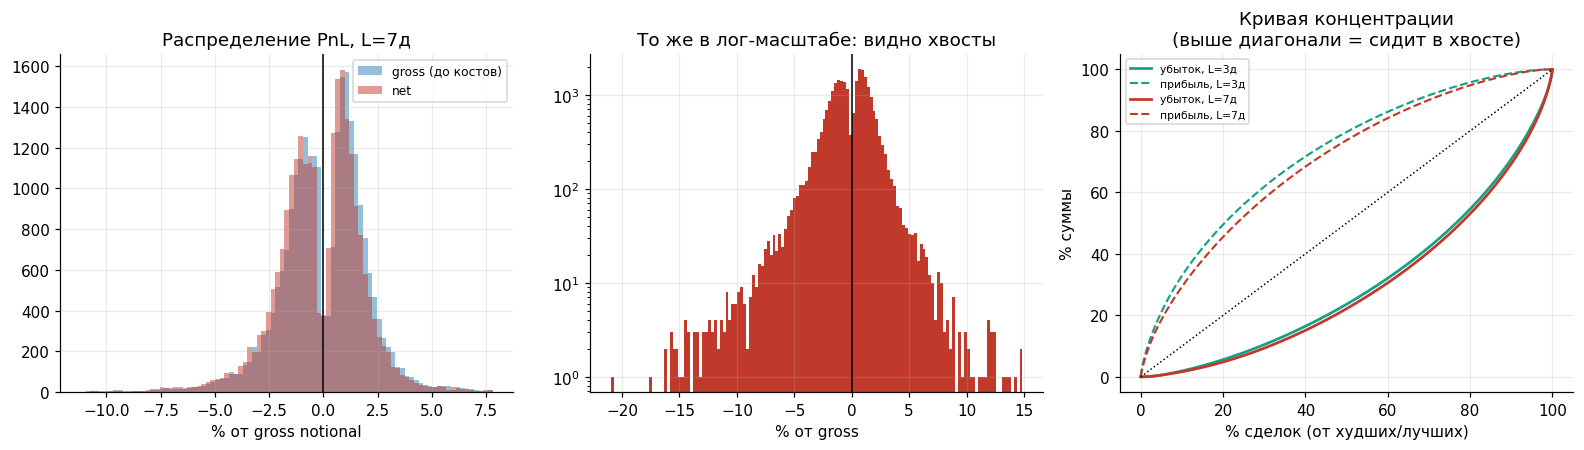

In [5]:
rows = []
for L in LD:
    v = np.sort(TRD[L].pnl.values)
    tot_loss = -v[v < 0].sum()
    tot_gain = v[v > 0].sum()
    n = len(v)
    for k in [0.1, 0.5, 1, 2, 5, 10]:
        m = max(int(n*k/100), 1)
        rows.append({"L, дн": L, "k, %": k, "сделок в k%": m,
                     "доля убытка от худших k%": round(-v[:m].sum()/tot_loss*100, 1),
                     "доля прибыли от лучших k%": round(v[-m:].sum()/tot_gain*100, 1),
                     "E без худших k% %": round(v[m:].mean(), 3),
                     "E без лучших k% %": round(v[:-m].mean(), 3)})
C = pd.DataFrame(rows)
print("КОНЦЕНТРАЦИЯ ХВОСТОВ (net)")
print(C.to_string(index=False))
print()
print("как читать: если 'E без худших 1%' уже положительно — вся отрицательность")
print("ожидания живёт в 1% сделок, и это задача про стоп, а не про сигнал.")
print()
for L in LD:
    v = np.sort(TRD[L].pnl.values)
    n = len(v)
    flip = None
    for k in [0.1, 0.25, 0.5, 1, 2, 3, 5, 10, 20]:
        if v[max(int(n*k/100), 1):].mean() > 0:
            flip = k
            break
    print(f"L={L}д: ожидание становится положительным, если отрезать "
          f"{flip if flip else '>20'}% худших сделок"
          + ("" if flip else " (то есть хвост не объясняет минус)"))

# сколько сделок утопили именно косты
print()
print("РОЛЬ КОСТОВ В ФОРМЕ РАСПРЕДЕЛЕНИЯ:")
for L in LD:
    d = TRD[L]
    flipped = ((d.gross > 0) & (d.pnl < 0)).mean()*100
    print(f"  L={L}д: {flipped:.1f}% сделок были в плюсе ДО костов и в минусе ПОСЛЕ; "
          f"доля плюсовых падает {(d.gross>0).mean()*100:.1f}% -> {(d.pnl>0).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
L = 7
d = TRD[L]
bins = np.linspace(np.percentile(d.pnl, 0.2), np.percentile(d.pnl, 99.8), 90)
ax[0].hist(d.gross, bins=bins, alpha=0.5, label="gross (до костов)", color="#2980b9")
ax[0].hist(d.pnl, bins=bins, alpha=0.5, label="net", color="#c0392b")
ax[0].axvline(0, color="black", lw=1)
ax[0].set_title(f"Распределение PnL, L={L}д"); ax[0].set_xlabel("% от gross notional")
ax[0].legend(fontsize=8)

ax[1].hist(d.pnl, bins=140, color="#c0392b")
ax[1].set_yscale("log"); ax[1].axvline(0, color="black", lw=1)
ax[1].set_title("То же в лог-масштабе: видно хвосты"); ax[1].set_xlabel("% от gross")

for L_, c in [(3, "#16a085"), (7, "#c0392b")]:
    v = np.sort(TRD[L_].pnl.values)
    neg = -v[v < 0][::-1]
    ax[2].plot(np.arange(1, len(neg)+1)/len(neg)*100, np.cumsum(neg)/neg.sum()*100,
               lw=1.8, color=c, label=f"убыток, L={L_}д")
    pos = v[v > 0][::-1]
    ax[2].plot(np.arange(1, len(pos)+1)/len(pos)*100, np.cumsum(pos)/pos.sum()*100,
               lw=1.4, ls="--", color=c, label=f"прибыль, L={L_}д")
ax[2].plot([0, 100], [0, 100], color="black", lw=1, ls=":")
ax[2].set_xlabel("% сделок (от худших/лучших)"); ax[2].set_ylabel("% суммы")
ax[2].set_title("Кривая концентрации\n(выше диагонали = сидит в хвосте)")
ax[2].legend(fontsize=7)
show("nb07_shape")

## 3. Откуда именно берётся минус: разбор по причине выхода

Здесь и должен вскрыться механизм. У правила три выхода, и у каждого своя
геометрия PnL:

- **target** (|z| < 0.5) — ход ≈ 1.5σ, **ограничен сверху** правилом;
- **zstop** (|z| > 4) — ход ≈ −2σ, тоже фиксированный, но убыточный;
- **time** (истёк лимит 2L) — ход **не ограничен ничем**, куда угодно.

Если минус сидит в `time`, то дело не в «плохом сигнале»: это позиции, которые
не вернулись, и мы просто ждали до конца лимита. Если в `zstop` — сигнал входил
против продолжающегося расхождения.

In [6]:
for L in LD:
    d = TRD[L]
    t = d.groupby("reason").agg(
        сделок=("pnl", "size"),
        доля_пр=("pnl", lambda v: round(len(v)/len(d)*100, 1)),
        ср_gross=("gross", "mean"), ср_net=("pnl", "mean"),
        ср_σ=("sigma", "mean"), медиана_ч=("hours", "median"),
        плюс_пр=("pnl", lambda v: round((v > 0).mean()*100, 1)),
        вклад_в_сумму=("pnl", "sum")).round(3)
    t["вклад, % от итога"] = (t.вклад_в_сумму / d.pnl.sum() * 100).round(1)
    print(f"L={L}д, разбор по причине выхода (итого {d.pnl.sum():.0f}% суммарно, "
          f"{d.pnl.mean():+.3f}% в среднем)")
    print(t.to_string())
    print()

print("ОЖИДАНИЕ ПО ГЕОМЕТРИИ ПРАВИЛА (вход 2σ, цель 0.5σ, стоп 4σ):")
print("  target -> ход +1.5σ, zstop -> ход -2.0σ, time -> ход не ограничен")
print("Сверяем с фактическим средним ходом в σ:")
for L in LD:
    d = TRD[L]
    g = d.groupby("reason").sigma.mean().round(2)
    print(f"  L={L}д: " + ", ".join(f"{k} {v:+.2f}σ" for k, v in g.items()))

L=3д, разбор по причине выхода (итого -9542% суммарно, -0.165% в среднем)
        сделок  доля_пр  ср_gross  ср_net   ср_σ  медиана_ч  плюс_пр  вклад_в_сумму  вклад, % от итога
reason                                                                                                
target   27660     47.8     1.055   0.845  1.799        9.0     89.3      23385.222             -245.1
time        26      0.0     0.141  -0.069  0.281        5.5     26.9         -1.801                0.0
zstop    30150     52.1    -0.882  -1.092 -1.560        4.0      4.2     -32925.270              345.1

L=7д, разбор по причине выхода (итого -4813% суммарно, -0.191% в среднем)
        сделок  доля_пр  ср_gross  ср_net   ср_σ  медиана_ч  плюс_пр  вклад_в_сумму  вклад, % от итога
reason                                                                                                
target   13445     53.4     1.313   1.103  1.613       15.0     91.0      14827.671             -308.1
time        46      0.2    

## 4. Асимметрия реальна или её создало правило?

Ключевая проверка. Прогоняем **то же самое** на перемешанных доходностях: связи
между активами нет по построению, значит любая форма распределения там — чистое
следствие правила «2σ → 0.5σ / стоп 4σ / таймаут».

- Если асимметрия у синтетики такая же → наша `L/W` не говорит ничего о рынке,
  это отпечаток правила выхода, и «лечить хвост» бессмысленно: он встроен.
- Если у реальности хвост **толще** → есть добавка от рынка (совместные
  расхождения), и её можно и нужно резать.

синтетика L=3д: сделок 11238, среднее -0.291%


синтетика L=7д: сделок 10116, среднее -0.191%

ФОРМА: РЕАЛЬНОСТЬ ПРОТИВ СИНТЕТИКИ (net)
 L, дн     данные  p, % плюс   W %   L %  L/W  скошенность  q1 %  q99 %  |q0.1| %    E %  ход gross, σ
     3 реальность       44.9 1.153 1.239 1.07         0.20 -4.35   4.37      8.82 -0.165         0.048
     3  синтетика       42.8 2.400 2.302 0.96         0.43 -7.13   7.57     11.88 -0.291        -0.053
     7 реальность       49.6 1.422 1.781 1.25        -0.67 -6.75   5.10     13.27 -0.191         0.048
     7  синтетика       50.3 2.991 3.406 1.14        -0.24 -9.79   7.06     15.25 -0.191         0.006

L=3д: L/W реальность 1.07 против синтетики 0.96; худший 0.1% 8.82% против 11.88%
       -> асимметрия ВСТРОЕНА в правило
L=7д: L/W реальность 1.25 против синтетики 1.14; худший 0.1% 13.27% против 15.25%
       -> асимметрия ВСТРОЕНА в правило


[saved] notebooks\statarb\_out\nb07_vs_null.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb07_vs_null.png')

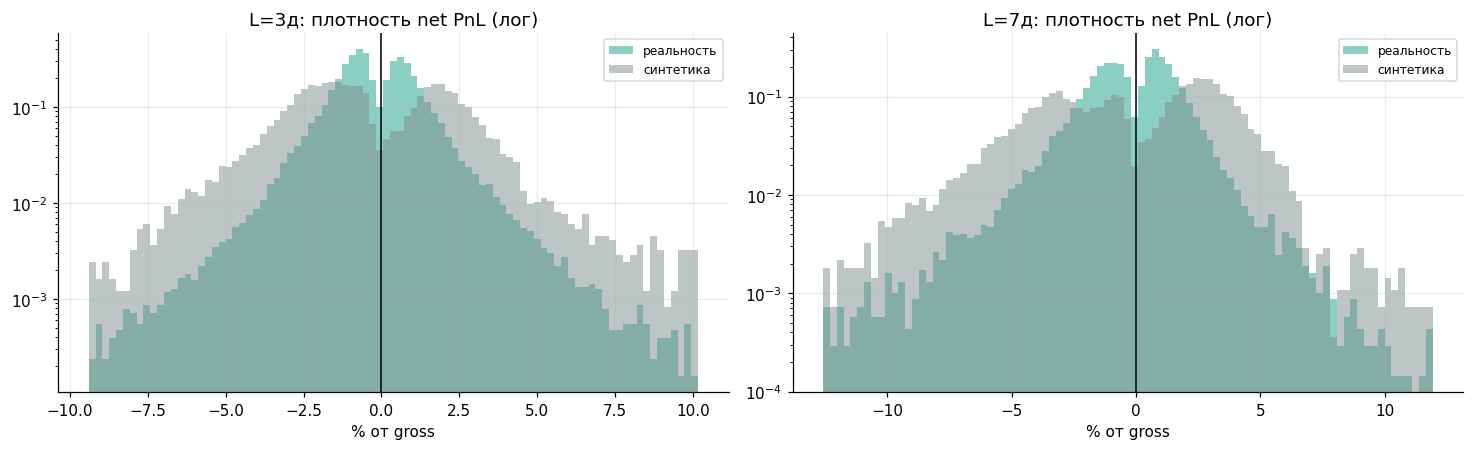

In [7]:
bk_n = bk.with_panel(shuffled(bk.M, seed=99))
NUL = {}
for L in LD:
    n = bk.nbars(L)
    thr = calibrate_thr(bk_n, n)
    R = refit(bk_n, n, thr)
    NUL[L] = sweep(bk_n, R, "REFIT", cost_pct=COST)
    print(f"синтетика L={L}д: сделок {len(NUL[L])}, среднее {NUL[L].pnl.mean():+.3f}%")

rows = []
for L in LD:
    for tag, d in [("реальность", TRD[L]), ("синтетика", NUL[L])]:
        v = d.pnl
        w = v[v > 0]; l = -v[v < 0]
        rows.append({"L, дн": L, "данные": tag,
                     "p, % плюс": round((v > 0).mean()*100, 1),
                     "W %": round(w.mean(), 3), "L %": round(l.mean(), 3),
                     "L/W": round(l.mean()/w.mean(), 2),
                     "скошенность": round(float(sps.skew(v)), 2),
                     "q1 %": round(np.percentile(v, 1), 2),
                     "q99 %": round(np.percentile(v, 99), 2),
                     "|q0.1| %": round(abs(np.percentile(v, 0.1)), 2),
                     "E %": round(v.mean(), 3),
                     "ход gross, σ": round(d.sigma.mean(), 3)})
CMP = pd.DataFrame(rows)
print("\nФОРМА: РЕАЛЬНОСТЬ ПРОТИВ СИНТЕТИКИ (net)")
print(CMP.to_string(index=False))
print()
for L in LD:
    a = CMP[(CMP["L, дн"] == L) & (CMP.данные == "реальность")].iloc[0]
    b = CMP[(CMP["L, дн"] == L) & (CMP.данные == "синтетика")].iloc[0]
    print(f"L={L}д: L/W реальность {a['L/W']:.2f} против синтетики {b['L/W']:.2f}; "
          f"худший 0.1% {a['|q0.1| %']:.2f}% против {b['|q0.1| %']:.2f}%")
    verdict = ("асимметрия ВСТРОЕНА в правило" if abs(a["L/W"] - b["L/W"]) < 0.15
               else "у реальности асимметрия ОТЛИЧАЕТСЯ -> есть рыночная добавка")
    print(f"       -> {verdict}")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
for k, L in enumerate(LD):
    dr, dn = TRD[L].pnl, NUL[L].pnl
    lo = min(np.percentile(dr, 0.3), np.percentile(dn, 0.3))
    hi = max(np.percentile(dr, 99.7), np.percentile(dn, 99.7))
    bins = np.linspace(lo, hi, 90)
    ax[k].hist(dr, bins=bins, density=True, alpha=0.5, color="#16a085", label="реальность")
    ax[k].hist(dn, bins=bins, density=True, alpha=0.5, color="#7f8c8d", label="синтетика")
    ax[k].set_yscale("log"); ax[k].axvline(0, color="black", lw=1)
    ax[k].set_title(f"L={L}д: плотность net PnL (лог)"); ax[k].set_xlabel("% от gross")
    ax[k].legend(fontsize=8)
show("nb07_vs_null")

## 5. Когда именно случается убыток

nb04 показал на месячных окнах, что хвост не диверсифицируется: убытки приходят
одновременно по десяткам пар, потому что причина у них общая (рынок пошёл в тренд).
Проверяем, сохраняется ли это на коротких окнах с ежедневным рефитом — от этого
зависит, спасает ли вообще портфельная диверсификация.

L=7д: 12 худших ДНЕЙ по сумме PnL всех сделок, открытых в этот день
                              sum  size  mean
day                                          
2024-12-09 00:00:00+00:00 -410.90   101 -4.07
2024-03-05 00:00:00+00:00 -321.89   113 -2.85
2024-08-20 00:00:00+00:00 -204.43   126 -1.62
2024-03-06 00:00:00+00:00 -165.79    64 -2.59
2024-08-02 00:00:00+00:00 -157.04   101 -1.55
2024-03-09 00:00:00+00:00 -153.40    76 -2.02
2024-03-15 00:00:00+00:00 -143.77   359 -0.40
2024-03-14 00:00:00+00:00 -120.63   123 -0.98
2024-09-09 00:00:00+00:00 -118.93    57 -2.09
2025-03-24 00:00:00+00:00 -117.87    76 -1.55
2024-04-09 00:00:00+00:00 -115.65    95 -1.22
2025-05-19 00:00:00+00:00 -112.33    95 -1.18

всего дней с входами: 541, сумма PnL по всем сделкам -4813%
  5 худших дней (0.9% дней) дают 26% всего итога
  10 худших дней (1.8% дней) дают 40% всего итога
  20 худших дней (3.7% дней) дают 61% всего итога

ПО МЕСЯЦАМ:
            sum  size  mean
t_in                       
2024-01 -

C:\Users\nvisary\AppData\Local\Temp\ipykernel_40268\369641815.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.agg(["sum", "size", "mean"])


[saved] notebooks\statarb\_out\nb07_clusters.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb07_clusters.png')

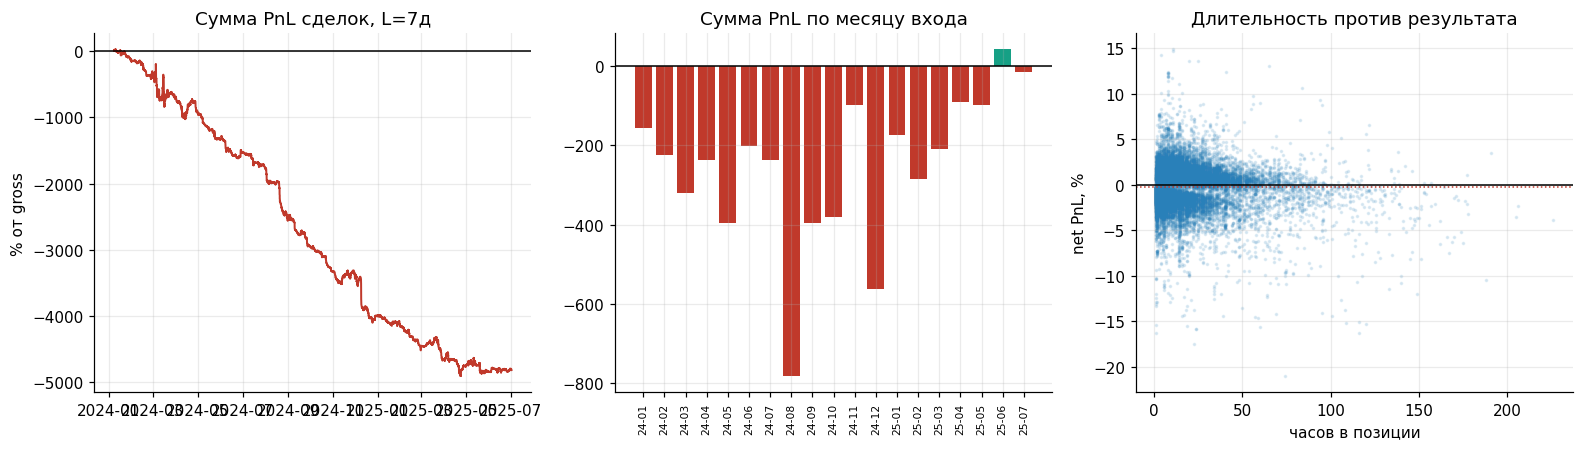

In [8]:
L = 7
d = TRD[L].copy()
d["day"] = d.t_in.dt.floor("D")
byday = d.groupby("day").pnl.agg(["sum", "size", "mean"])
worst = byday.sort_values("sum").head(12)
print(f"L={L}д: 12 худших ДНЕЙ по сумме PnL всех сделок, открытых в этот день")
print(worst.round(2).to_string())
print()
n_days = byday.shape[0]
print(f"всего дней с входами: {n_days}, сумма PnL по всем сделкам {d.pnl.sum():.0f}%")
for k in [5, 10, 20]:
    share = byday.sort_values("sum").head(k)["sum"].sum() / d.pnl.sum() * 100
    print(f"  {k} худших дней ({k/n_days*100:.1f}% дней) дают {share:.0f}% всего итога")

bym = d.groupby(d.t_in.dt.to_period("M")).pnl.agg(["sum", "size", "mean"])
print()
print("ПО МЕСЯЦАМ:")
print(bym.round(2).to_string())
print(f"плюсовых месяцев {(bym['sum']>0).sum()} из {len(bym)}")

# одновременность: сколько позиций открыто в момент худших входов
def max_concurrent(iv):
    ev = [(a, 1) for a, _ in iv] + [(b, -1) for _, b in iv]
    ev.sort(key=lambda e: (e[0], e[1]))     # выход раньше входа при равной метке
    cur = best = 0
    for _, dd in ev:
        cur += dd; best = max(best, cur)
    return best

iv = list(zip(d.i_in.values, d.i_out.values))
print()
print(f"максимум одновременно открытых позиций (все пары): {max_concurrent(iv)}")
loss = d[d.pnl < np.percentile(d.pnl, 1)]
iv_l = list(zip(loss.i_in.values, loss.i_out.values))
print(f"максимум одновременных среди 1% худших сделок: {max_concurrent(iv_l)} "
      f"(из {len(loss)} таких сделок)")
print(f"уникальных пар среди 1% худших: {loss.pair.nunique()} из {d.pair.nunique()}")
print(f"дней, на которые приходится 1% худших: {loss.t_in.dt.floor('D').nunique()} "
      f"из {n_days}")

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
ax[0].plot(d.sort_values("t_in").t_in.values, d.sort_values("t_in").pnl.cumsum().values,
           lw=1.3, color="#c0392b")
ax[0].axhline(0, color="black", lw=1)
ax[0].set_title(f"Сумма PnL сделок, L={L}д"); ax[0].set_ylabel("% от gross")
ax[1].bar(range(len(bym)), bym["sum"].values,
          color=["#16a085" if v > 0 else "#c0392b" for v in bym["sum"].values])
ax[1].set_xticks(range(len(bym))); ax[1].set_xticklabels([str(p)[2:] for p in bym.index],
                                                         rotation=90, fontsize=7)
ax[1].axhline(0, color="black", lw=1); ax[1].set_title("Сумма PnL по месяцу входа")
ax[2].scatter(d.hours, d.pnl, s=2, alpha=0.12, color="#2980b9")
ax[2].axhline(0, color="black", lw=1); ax[2].axhline(-COST, color="#c0392b", ls=":", lw=1)
ax[2].set_xlabel("часов в позиции"); ax[2].set_ylabel("net PnL, %")
ax[2].set_title("Длительность против результата")
show("nb07_clusters")

## 6. Что даёт резка хвоста

Если убыток концентрирован, стоп должен помогать. Но у стопа есть цена: он
превращает часть возвращающихся позиций в фиксированный минус. Меряем сетку
«уровень стопа × лимит удержания», удерживая **полосу входа фиксированной**
(2σ..4σ) — иначе снижение стопа заодно сужает вход и мы сравниваем разные
стратегии.

Отдельно смотрим, что было бы при **maker-косте** ~6 bps вместо taker 21 bps:
из nb06 известно, что gross на коротких окнах положителен, поэтому уровень
костов может решать исход целиком.

In [9]:
L = 7
R = REF[L]
n = bk.nbars(L)
rows = []
for zstop in [2.5, 3.0, 4.0, 6.0]:
    for hm in [0.5, 1.0, 2.0]:
        d = sweep(bk, R, "REFIT", zstop=zstop, zcap=4.0,
                  max_hold=int(hm*n), cost_pct=COST)
        if not len(d):
            continue
        v = d.pnl
        w = v[v > 0]; l = -v[v < 0]
        rows.append({"стоп σ": zstop, "лимит, L": hm, "сделок": len(d),
                     "E net %": round(v.mean(), 3),
                     "E gross %": round(d.gross.mean(), 3),
                     "E при maker 6bps %": round(d.gross.mean() - 0.06, 3),
                     "L/W": round(l.mean()/w.mean(), 2),
                     "% плюс": round((v > 0).mean()*100, 1),
                     "худшая %": round(v.min(), 1),
                     "медиана ч": int(d.hours.median()),
                     "E/std": round(v.mean()/v.std(), 3)})
FX = pd.DataFrame(rows)
print(f"СЕТКА ЗАЩИТЫ, L={L}д, полоса входа фиксирована 2σ..4σ")
print(FX.to_string(index=False))
print()
best_g = FX.sort_values("E gross %", ascending=False).iloc[0]
best_n = FX.sort_values("E net %", ascending=False).iloc[0]
print(f"лучшая по GROSS: стоп {best_g['стоп σ']}σ / лимит {best_g['лимит, L']}L -> "
      f"{best_g['E gross %']:+.3f}% (net {best_g['E net %']:+.3f}%)")
print(f"лучшая по NET:   стоп {best_n['стоп σ']}σ / лимит {best_n['лимит, L']}L -> "
      f"{best_n['E net %']:+.3f}%")
print()
mk = FX[FX["E при maker 6bps %"] > 0]
if len(mk):
    print(f"ячеек, положительных при maker-косте 6 bps: {len(mk)} из {len(FX)}")
    print(mk[["стоп σ", "лимит, L", "сделок", "E при maker 6bps %", "E/std"]].to_string(index=False))
else:
    print("ни одна ячейка не выходит в плюс даже при maker-косте 6 bps")

СЕТКА ЗАЩИТЫ, L=7д, полоса входа фиксирована 2σ..4σ
 стоп σ  лимит, L  сделок  E net %  E gross %  E при maker 6bps %  L/W  % плюс  худшая %  медиана ч  E/std
    2.5       0.5   63064   -0.216     -0.006              -0.066 0.64    25.3     -16.2          1 -0.214
    2.5       1.0   63064   -0.216     -0.006              -0.066 0.64    25.3     -16.2          1 -0.214
    2.5       2.0   63064   -0.216     -0.006              -0.066 0.64    25.3     -16.2          1 -0.214
    3.0       0.5   45019   -0.215     -0.005              -0.065 0.68    30.2     -16.2          2 -0.158
    3.0       1.0   45016   -0.216     -0.006              -0.066 0.68    30.2     -16.2          2 -0.158
    3.0       2.0   45016   -0.216     -0.006              -0.066 0.68    30.2     -16.2          2 -0.158
    4.0       0.5   25182   -0.195      0.015              -0.045 1.25    49.5     -21.0         10 -0.091
    4.0       1.0   25175   -0.192      0.018              -0.042 1.25    49.6     -21.0    

## 7. Итог

In [10]:
print("ЧТО ИЗМЕРЕНО\n")
for L in LD:
    a = CMP[(CMP["L, дн"] == L) & (CMP.данные == "реальность")].iloc[0]
    b = CMP[(CMP["L, дн"] == L) & (CMP.данные == "синтетика")].iloc[0]
    v = TRD[L].pnl.values
    n = len(v); vs = np.sort(v)
    w1 = -vs[:max(n//100, 1)].sum() / -vs[vs < 0].sum() * 100
    print(f"L={L}д:")
    print(f"  средний плюс {a['W %']:.3f}% против среднего минуса {a['L %']:.3f}% "
          f"-> L/W = {a['L/W']:.2f}   (синтетика {b['L/W']:.2f})")
    print(f"  доля плюсовых {a['p, % плюс']:.1f}%, нужно "
          f"{a['L %']/(a['W %']+a['L %'])*100:.1f}% для нуля")
    print(f"  1% худших сделок несёт {w1:.0f}% всего убытка")
    print(f"  E без 1% худших: {vs[max(n//100,1):].mean():+.3f}%")
    print()

ЧТО ИЗМЕРЕНО

L=3д:
  средний плюс 1.153% против среднего минуса 1.239% -> L/W = 1.07   (синтетика 0.96)
  доля плюсовых 44.9%, нужно 51.8% для нуля
  1% худших сделок несёт 9% всего убытка
  E без 1% худших: -0.103%

L=7д:
  средний плюс 1.422% против среднего минуса 1.781% -> L/W = 1.25   (синтетика 1.14)
  доля плюсовых 49.6%, нужно 55.6% для нуля
  1% худших сделок несёт 10% всего убытка
  E без 1% худших: -0.099%

